<img src="Logo_UNSAM.png" width="180">

### Análisis y Procesamiento de Señales

# Trabajo Práctico N°5: Estimación espectral: ancho de banda de señales reales 

### Paulina Benito

#### Introducción

El análisis espectral permite estudiar cómo se distribuye la potencia de una señal en función de la frecuencia y resulta una herramienta fundamental para caracterizar señales reales. A diferencia de las señales ideales, los registros experimentales suelen presentar ruido, variaciones temporales y componentes espectrales distribuidas en un determinado rango de frecuencias, por lo que es necesario recurrir a métodos de estimación espectral.

En este trabajo se analizarán distintos tipos de señales reales: un electrocardiograma (ECG), una señal de fotopletismografía (PPG) y registros de audio. Para cada una se estimará la densidad espectral de potencia (PSD) mediante alguno de los métodos estudiados en la materia, tales como el periodograma ventaneado, Welch o Blackman-Tukey. A partir de estas estimaciones se buscará identificar la distribución de potencia en frecuencia y obtener una estimación del ancho de banda de cada señal.
Finalmente, se compararán los resultados obtenidos entre los distintos registros, teniendo en cuenta las características espectrales propias de cada tipo de señal y las particularidades del método de estimación utilizado.

#### 1. ECG

En la siguiente sección se trabajará con el ECG sin ruido. 

30000


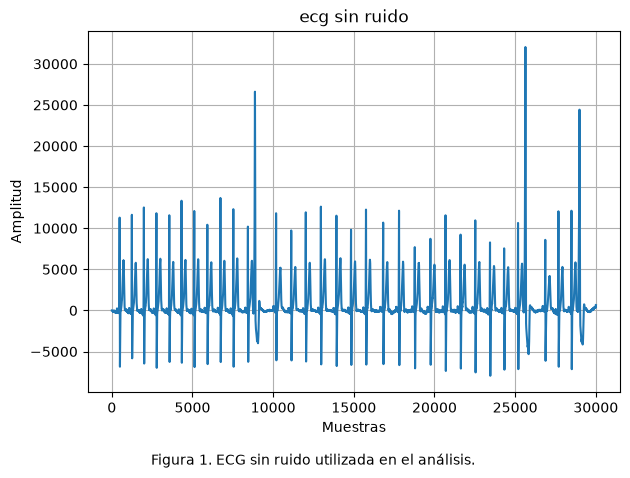

In [28]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt 
import scipy.io as sio
from scipy.io.wavfile import write

##Lectura del ECG 
fs_ecg = 1000 # Hz

# para listar las variables que hay en el archivo
sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')
ecg_one_lead = np.load('ecg_sin_ruido.npy')

plt.figure()
plt.plot(ecg_one_lead)
plt.title("ecg sin ruido")
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid()
plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 1. ECG sin ruido utilizada en el análisis. ",
            ha="center")
print(len(ecg_one_lead))

Se estimó la PSD del ECG mediante el método de Welch utilizando distintas longitudes de segmento $L$. A la izquierda se presenta el espectro completo y a la derecha una ampliación de la región de bajas frecuencias, donde se concentra la mayor parte del contenido espectral. Esta comparación permite analizar el compromiso entre resolución espectral y variabilidad de la estimación para seleccionar una longitud de segmento adecuada.

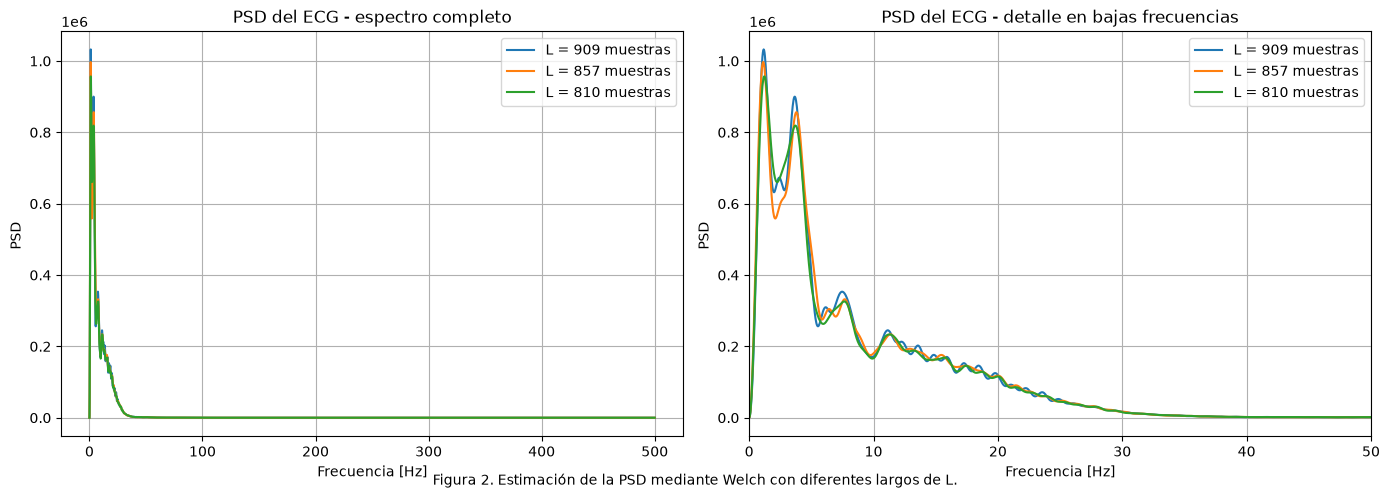

In [29]:
N=30000
L= np.array([N/33, N/35, N/37])
K=N/L
arrwelch_ECG=[]
for l in L:
    welch_ECG = sig.welch(
        ecg_one_lead,
        fs_ecg,
        'boxcar',
        int(l),
        int(l/2),
        N
    )
    
    arrwelch_ECG.append(welch_ECG)
plt.figure(figsize=(14,5))

# ESPECTRO COMPLETO
plt.subplot(1,2,1)

for i in range(len(arrwelch_ECG)):
    plt.plot(
        arrwelch_ECG[i][0],
        arrwelch_ECG[i][1],
        label=f'L = {int(L[i])} muestras'
    )

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD ')
plt.title('PSD del ECG - espectro completo')
plt.legend()
plt.grid()

# ZOOM
plt.subplot(1,2,2)

for i in range(len(arrwelch_ECG)):
    plt.plot(
        arrwelch_ECG[i][0],
        arrwelch_ECG[i][1],
        label=f'L = {int(L[i])} muestras'
    )

plt.xlim(0, 50)   
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD ')
plt.title('PSD del ECG - detalle en bajas frecuencias')
plt.legend()
plt.grid()

plt.tight_layout()
plt.figtext(0.5, 0.02,
            "Figura 2. Estimación de la PSD mediante Welch con diferentes largos de L.",
            ha="center")
plt.show()

Como se observa en la Figura 2, se compararon tres longitudes de segmento para la estimación de la PSD mediante Welch. Al aumentar $L$, mejora la resolución espectral, aunque disminuye la cantidad de segmentos disponibles para promediar. En cambio, segmentos más cortos permiten realizar más promedios y obtener una estimación más estable, a costa de una menor resolución. A partir de la comparación se seleccionó $L=N/35$, aproximadamente 857 muestras, debido a que se mantienen bien los detalles y  no presenta alta variabilidad.

Para caracterizar el contenido espectral del ECG, además de estimar su densidad espectral de potencia, se buscó determinar un ancho de banda representativo de la señal. Dado que una señal real puede presentar contenido de baja amplitud en un rango amplio de frecuencias, se adoptó un criterio basado en la proporción de energía espectral acumulada.

Se definió como ancho de banda la frecuencia por debajo de la cual se concentra el 98% de la energía espectral acumulada. Se eligió este porcentaje como un compromiso entre incluir prácticamente todo el contenido energético relevante de la señal y evitar que componentes de muy baja energía en frecuencias más altas amplíen excesivamente la estimación del ancho de banda.  
Como referencia, utilizando un criterio del 95% se obtuvo un valor de 23,3 Hz, mientras que al considerar el 98% el ancho de banda aumentó a 28,23 Hz. Por este motivo, se consideró que el 98% permitía representar de manera más completa el contenido espectral de la señal sin recurrir a un criterio tan exigente como el 99%.

Para obtener este valor, se calculó la suma acumulada de la PSD estimada mediante Welch y luego se normalizó respecto de su valor total. Finalmente, se identificó la primera frecuencia para la cual la energía acumulada alcanzó el 98%.

In [30]:
f = arrwelch_ECG[1][0]
Pxx = arrwelch_ECG[1][1]

energia_acum = np.cumsum(Pxx)   #suma acumulada de potencias
energia_acum = energia_acum / energia_acum[-1]  #normalizo con el ulitmo valor del vector

for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.98:
        f_98 = f[i]
        break

print("Ancho de banda:", f_98, "Hz")

Ancho de banda: 28.233333333333334 Hz


Aplicando este criterio, se obtuvo un ancho de banda estimado de 28,23 Hz para la señal ECG.

#### 2. PPG

Text(0.5, 0.02, 'Figura 3. PPG sin ruido utilizada en el análisis. ')

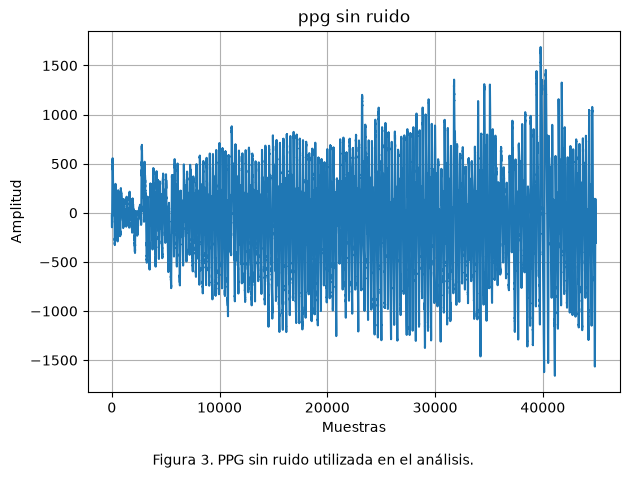

In [32]:
fs_ppg = 400 # Hz
ppg = np.load('ppg_sin_ruido.npy')
plt.figure()
plt.plot(ppg)
plt.title("ppg sin ruido")
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid()
plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 3. PPG sin ruido utilizada en el análisis. ",
            ha="center")


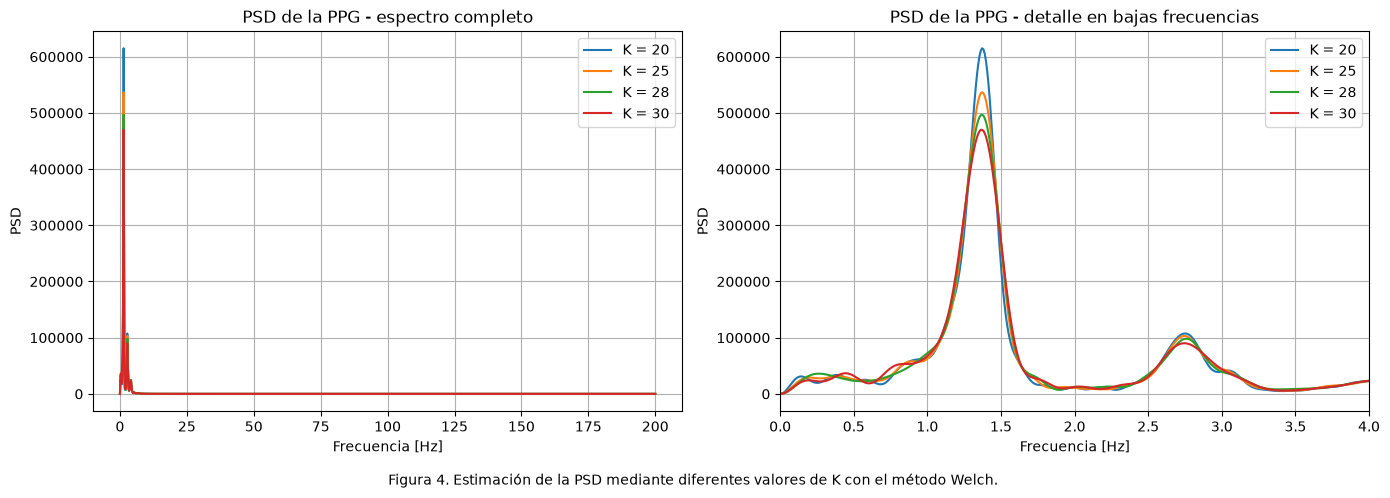

In [38]:
N = len(ppg)
K = np.array([20,25,28, 30])
L = N / K
arrwelch_PPG = []
for l in L:
    welch_PPG = sig.welch(
        ppg,
        fs_ppg,
        window='boxcar',
        nperseg=int(l),
        noverlap=int(l/2),
        nfft=N
    )
    
    arrwelch_PPG.append(welch_PPG)
    
plt.figure(figsize=(14,5))

# ESPECTRO COMPLETO
plt.subplot(1,2,1)

for i in range(len(arrwelch_PPG)):
    plt.plot(
        arrwelch_PPG[i][0],
        arrwelch_PPG[i][1],
        label=f'K = {K[i]}'
    )

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD de la PPG - espectro completo')
plt.legend()
plt.grid()


# ZOOM
plt.subplot(1,2,2)

for i in range(len(arrwelch_PPG)):
    plt.plot(
        arrwelch_PPG[i][0],
        arrwelch_PPG[i][1],
        label=f'K = {K[i]}'
    )

plt.xlim(0, 4)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD de la PPG - detalle en bajas frecuencias')
plt.legend()
plt.grid()

plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 4. Estimación de la PSD mediante diferentes valores de K con el método Welch. ",
            ha="center")
plt.show()

Entre los valores analizados en la Figura 4, se seleccionó $K=28$, correspondiente a una longitud de segmento de aproximadamente 1604 muestras. Para valores menores de $K$, los segmentos son más largos y la estimación presenta una mayor resolución espectral, aunque con menor cantidad de segmentos disponibles para promediar. En cambio, al aumentar $K$, los segmentos se acortan y la estimación se suaviza más. En este caso, $K=28$ permitió conservar claramente los principales componentes espectrales de la señal PPG, sin perder de forma apreciable la definición de los picos y manteniendo al mismo tiempo una estimación suficientemente estable.

Para estimar el ancho de banda de la señal PPG se utilizó el mismo criterio aplicado al ECG, basado en la energía espectral acumulada. Se tomó como referencia la frecuencia por debajo de la cual se concentra el 98% de la energía total de la señal.

In [43]:
f = arrwelch_PPG[2][0]
Pxx = arrwelch_PPG[2][1]
energia_acum = np.cumsum(Pxx)
energia_acum = energia_acum / energia_acum[-1]
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.98:
        f_98 = f[i]
        break

print("Ancho de banda:", f_98, "Hz")

Ancho de banda: 4.862085086489014 Hz


Aplicando el criterio del 98% de energía espectral acumulada, se obtuvo un ancho de banda aproximado de $4,86 Hz$ para la señal PPG. Este resultado es coherente con la PSD estimada, donde se observa que los principales componentes espectrales se concentran en las bajas frecuencias y que por encima de ese valor el aporte energético es reducido.

#### 3. Audio

En esta sección se estimará la PSD y el ancho de banda de tres señales de audio diferentes. 

##### 3.1 La cucaracha

48000 144000


Text(0.5, 0.02, 'Figura 5. Señal de audio en dominio temporal. ')

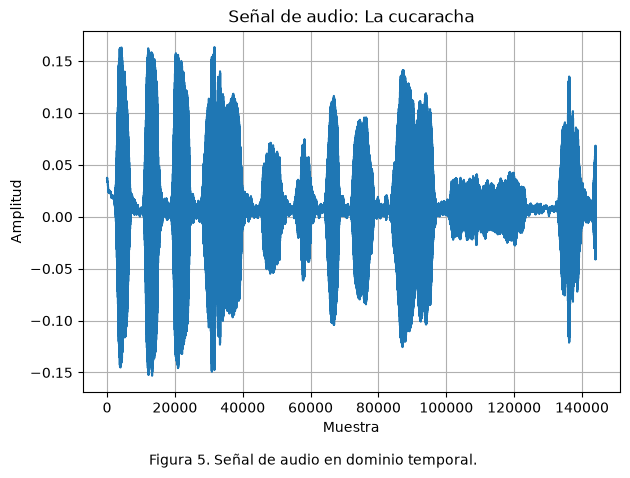

In [49]:
fs_audio1, wav_data1 = sio.wavfile.read('la cucaracha.wav')
print(fs_audio1, len(wav_data1))
plt.figure()
plt.plot(wav_data1)
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.title('Señal de audio: La cucaracha')
plt.grid()
plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 5. Señal de audio en dominio temporal. ",
            ha="center")

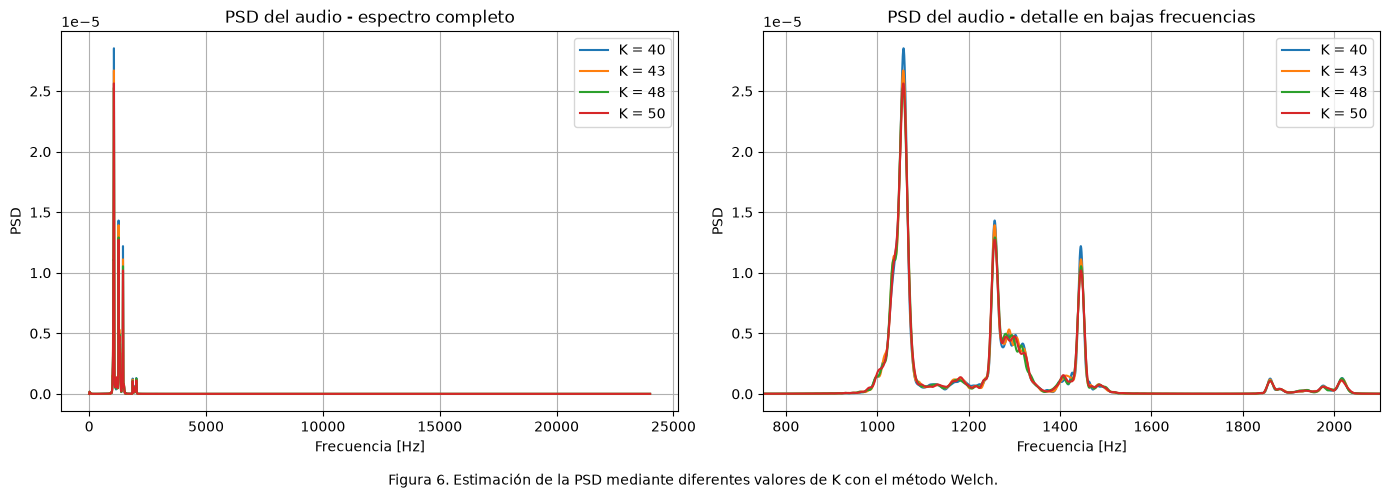

In [58]:
N = len(wav_data1)
K = np.array([40, 43, 48, 50])
L = N / K

arrwelch_audio1 = []
for l in L:
    welch_audio1 = sig.welch(
        wav_data1,
        fs_audio1,
        window='boxcar',
        nperseg=int(l),
        noverlap=int(l/2),
        nfft=N
    )
    
    arrwelch_audio1.append(welch_audio1)
plt.figure(figsize=(14,5))

# ESPECTRO COMPLETO
plt.subplot(1,2,1)

for i in range(len(arrwelch_audio1)):
    plt.plot(
        arrwelch_audio1[i][0],
        arrwelch_audio1[i][1],
        label=f'K = {K[i]}'
    )

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del audio - espectro completo')
plt.legend()
plt.grid()


# ZOOM
plt.subplot(1,2,2)

for i in range(len(arrwelch_audio1)):
    plt.plot(
        arrwelch_audio1[i][0],
        arrwelch_audio1[i][1],
        label=f'K = {K[i]}'
    )

plt.xlim(750, 2100)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del audio - detalle en bajas frecuencias')
plt.legend()
plt.grid()

plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 6. Estimación de la PSD mediante diferentes valores de K con el método Welch. ",
            ha="center")
plt.show()

Se seleccionó $K=48$, correspondiente a una longitud de segmento de 3000 muestras, como un compromiso adecuado entre resolución espectral y estabilidad de la estimación. Al aumentar $K$, la longitud de los segmentos disminuye, por lo que se dispone de una mayor cantidad de segmentos para promediar y la estimación de Welch tiende a ser más estable y suavizada. Sin embargo, segmentos más cortos implican una menor resolución espectral. En este caso, con $K=48$ los principales picos del espectro continúan claramente diferenciados, por lo que la pérdida de resolución no resulta significativa para el análisis realizado, mientras que se obtiene una estimación más estable que con valores menores de $K$.

Para estimar el ancho de banda del audio se utilizó el mismo criterio aplicado en las señales anteriores, considerando la frecuencia por debajo de la cual se concentra el 98% de la energía espectral acumulada. De esta manera se mantiene un criterio común que permite comparar posteriormente los resultados obtenidos entre las distintas señales.

In [56]:
f = arrwelch_audio1[2][0]
Pxx = arrwelch_audio1[2][1]
energia_acum = np.cumsum(Pxx)
energia_acum = energia_acum / energia_acum[-1]
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.98:
        f_98 = f[i]
        break

print("Ancho de banda:", f_98, "Hz")

Ancho de banda: 1982.3333333333333 Hz


Aplicando este criterio, se obtuvo un ancho de banda aproximado de 1982.3 Hz para el audio “La cucaracha”.

##### 3.2 Prueba psd

48000 144000


Text(0.5, 0.02, 'Figura 7. Señal de audio en dominio temporal. ')

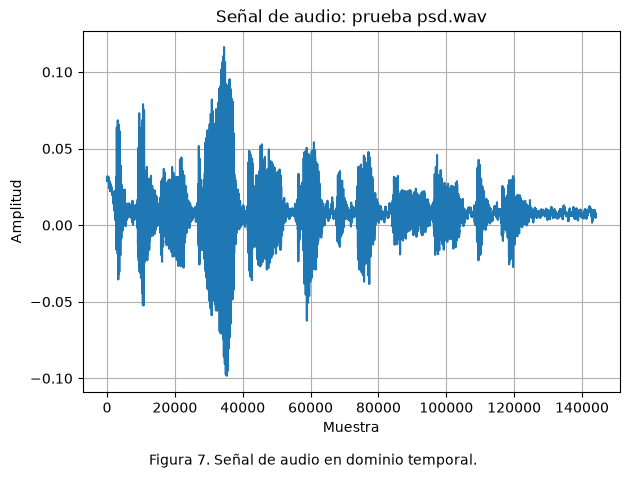

In [57]:
fs_audio2, wav_data2 = sio.wavfile.read('prueba psd.wav')
print(fs_audio2, len(wav_data2))
plt.figure()
plt.plot(wav_data2)
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.title('Señal de audio: prueba psd.wav')
plt.grid()
plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 7. Señal de audio en dominio temporal. ",
            ha="center")

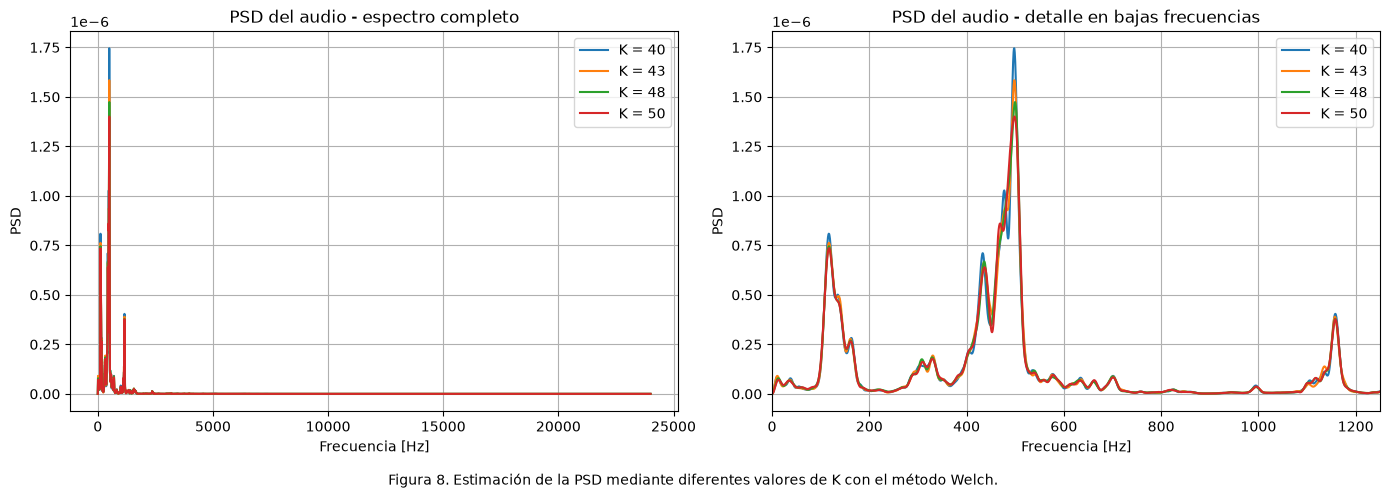

In [62]:
N = len(wav_data2)
K = np.array([40, 43, 48, 50])
L = N / K

arrwelch_audio2 = []
for l in L:
    welch_audio2 = sig.welch(
        wav_data2,
        fs_audio2,
        window='boxcar',
        nperseg=int(l),
        noverlap=int(l/2),
        nfft=N
    )
    
    arrwelch_audio2.append(welch_audio2)
plt.figure(figsize=(14,5))

# ESPECTRO COMPLETO
plt.subplot(1,2,1)

for i in range(len(arrwelch_audio2)):
    plt.plot(
        arrwelch_audio2[i][0],
        arrwelch_audio2[i][1],
        label=f'K = {K[i]}'
    )

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del audio - espectro completo')
plt.legend()
plt.grid()


# ZOOM
plt.subplot(1,2,2)

for i in range(len(arrwelch_audio2)):
    plt.plot(
        arrwelch_audio2[i][0],
        arrwelch_audio2[i][1],
        label=f'K = {K[i]}'
    )

plt.xlim(0, 1250)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del audio - detalle en bajas frecuencias')
plt.legend()
plt.grid()

plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 8. Estimación de la PSD mediante diferentes valores de K con el método Welch. ",
            ha="center")
plt.show()

Se analizaron valores de $K$ entre 40 y 50 y se observó que la ubicación de los principales componentes espectrales se mantiene prácticamente constante, aunque aparecen diferencias en su amplitud y en el grado de suavizado de la estimación. Se seleccionó $K=48$, correspondiente a una longitud de segmento de 3000 muestras, ya que permite mantener claramente diferenciados los principales componentes de la señal y, al mismo tiempo, disponer de una cantidad suficiente de segmentos para reducir la variabilidad mediante el promedio de Welch.

A continuación se estima el ancho de banda correspondiente:

In [64]:
f = arrwelch_audio2[2][0]
Pxx = arrwelch_audio2[2][1]
energia_acum = np.cumsum(Pxx)
energia_acum = energia_acum / energia_acum[-1]
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.98:
        f_98 = f[i]
        break

print("Ancho de banda:", f_98, "Hz")

Ancho de banda: 1648.0 Hz


Aplicando este criterio, se obtuvo un ancho de banda aproximado de 1648 Hz para el audio “prueba psd.wav”.

##### 3.3 Silbido

48000 144000


Text(0.5, 0.02, 'Figura 9. Señal de audio en dominio temporal. ')

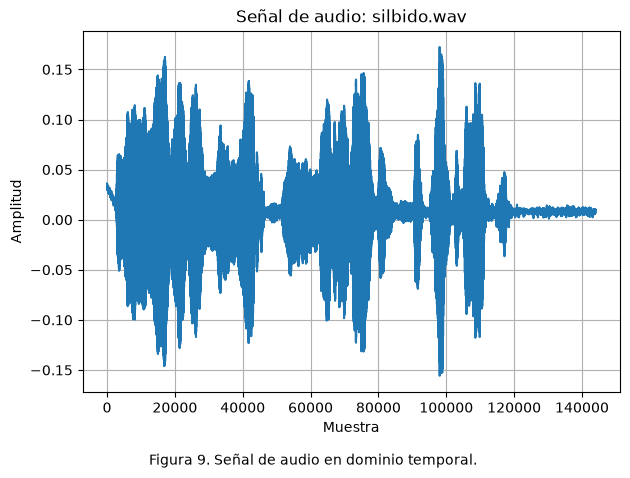

In [65]:
fs_audio3, wav_data3 = sio.wavfile.read('silbido.wav')
print(fs_audio3, len(wav_data3))
plt.figure()
plt.plot(wav_data3)
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.title('Señal de audio: silbido.wav')
plt.grid()
plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 9. Señal de audio en dominio temporal. ",
            ha="center")

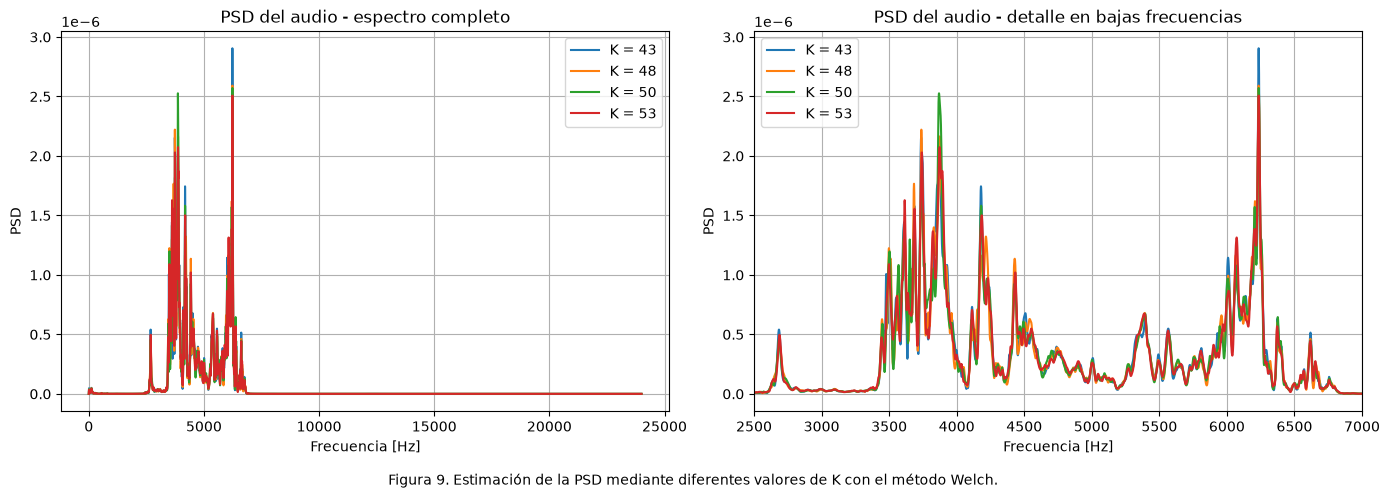

In [68]:
N = len(wav_data3)
K = np.array([43, 48, 50, 53])
L = N / K

arrwelch_audio3 = []
for l in L:
    welch_audio3 = sig.welch(
        wav_data3,
        fs_audio3,
        window='boxcar',
        nperseg=int(l),
        noverlap=int(l/2),
        nfft=N
    )
    
    arrwelch_audio3.append(welch_audio3)
plt.figure(figsize=(14,5))

# ESPECTRO COMPLETO
plt.subplot(1,2,1)

for i in range(len(arrwelch_audio3)):
    plt.plot(
        arrwelch_audio3[i][0],
        arrwelch_audio3[i][1],
        label=f'K = {K[i]}'
    )

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del audio - espectro completo')
plt.legend()
plt.grid()


# ZOOM
plt.subplot(1,2,2)

for i in range(len(arrwelch_audio3)):
    plt.plot(
        arrwelch_audio3[i][0],
        arrwelch_audio3[i][1],
        label=f'K = {K[i]}'
    )

plt.xlim(2500, 7000)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del audio - detalle en bajas frecuencias')
plt.legend()
plt.grid()

plt.tight_layout(rect=[0,0.05,1,1])
plt.figtext(0.5, 0.02,
            "Figura 9. Estimación de la PSD mediante diferentes valores de K con el método Welch. ",
            ha="center")
plt.show()

Se seleccionó $K=53$, correspondiente a una longitud de segmento de aproximadamente 2717 muestras. Al aumentar $K$, los segmentos utilizados por Welch son más cortos, lo que permite realizar una mayor cantidad de promedios y obtener una estimación más estable, aunque con una menor resolución espectral. En este caso, con $K=53$ los principales componentes del espectro continúan claramente diferenciados, por lo que la pérdida de resolución no resulta significativa para el análisis, mientras que se obtiene una estimación más suavizada y estable.

In [69]:
f = arrwelch_audio3[3][0]
Pxx = arrwelch_audio3[3][1]
energia_acum = np.cumsum(Pxx)
energia_acum = energia_acum / energia_acum[-1]
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.98:
        f_98 = f[i]
        break

print("Ancho de banda:", f_98, "Hz")

Ancho de banda: 6589.333333333333 Hz


Aplicando el criterio del 98% de energía espectral acumulada, se obtuvo un ancho de banda aproximado de 6589,33 Hz (6,59 kHz). Este resultado es consistente con la PSD estimada, donde se observa que los principales componentes espectrales se encuentran concentrados por debajo de aproximadamente 6,6 kHz.

#### Resultados

In [ ]:
import pandas as pd

datos = {
    'Señal': [
        'ECG',
        'PPG',
        'Audio 1 - La cucaracha',
        'Audio 2 - Prueba PSD',
        'Audio 3 - Silbido'
    ],

    'fs [Hz]': [
        fs_ecg,
        fs_ppg,
        fs_audio1,
        fs_audio2,
        fs_audio3
    ],

    'N': [
        len(ecg_one_lead),
        len(ppg),
        len(wav_data1),
        len(wav_data2),
        len(wav_data3)
    ],

    'K elegido': [
        35,
        28,
        48,
        48,     
        53
    ],

    'L [muestras]': [
        int(len(ecg_one_lead)/35),
        int(len(ppg)/28),
        int(len(wav_data1)/48),
        int(len(wav_data2)/48),   
        int(len(wav_data3)/53)
    ],

    'Ancho de banda [Hz]': [
        28.23,
        4.86,
        1982.33,
        1648.0,      
        6589.33
    ]
}

tabla_resultados = pd.DataFrame(datos)
tabla_resultados

Los resultados muestran diferencias claras entre las señales analizadas. La PPG presentó el menor ancho de banda, con 4,86 Hz, seguida por el ECG, con 28,23 Hz, lo que indica que ambas concentran la mayor parte de su contenido espectral en bajas frecuencias.

Las señales de audio presentaron anchos de banda considerablemente mayores. Para “Prueba PSD” se obtuvo 1648 Hz, para “La cucaracha” 1982,33 Hz, y para el silbido 6589,33 Hz, siendo esta última la señal con mayor contenido espectral distribuido en frecuencia.

Aunque los tres audios fueron adquiridos con la misma frecuencia de muestreo y la misma cantidad de muestras, sus anchos de banda fueron distintos, lo que muestra que este parámetro depende principalmente del contenido espectral de cada señal.

En todos los casos se utilizó el mismo criterio del 98% de energía espectral acumulada, lo que permitió comparar los resultados de forma consistente.

#### Conclusión

En este trabajo se analizaron señales reales de ECG, PPG y audio mediante técnicas de estimación espectral. Para cada registro se obtuvo una estimación de la densidad espectral de potencia utilizando el método de Welch, evaluando diferentes longitudes de segmento para encontrar un equilibrio entre resolución espectral y estabilidad de la estimación.

A partir de las PSD obtenidas se estimó el ancho de banda utilizando como criterio la frecuencia por debajo de la cual se concentra el 98% de la energía espectral acumulada. Este criterio permitió aplicar una misma metodología a señales de naturaleza muy diferente y comparar sus características espectrales de manera uniforme.

Los resultados mostraron que las señales fisiológicas analizadas presentan un contenido concentrado principalmente en bajas frecuencias, obteniéndose anchos de banda de 4,86 Hz para la PPG y 28,23 Hz para el ECG. Las señales de audio, en cambio, presentaron rangos espectrales considerablemente mayores, con valores de aproximadamente 1,65 kHz, 1,98 kHz y 6,59 kHz, dependiendo del registro analizado.

En conjunto, el trabajo permitió observar cómo la estimación de la PSD permite caracterizar señales reales y cómo la elección de los parámetros del estimador influye en la representación obtenida. Además, se comprobó que el ancho de banda no depende únicamente de las condiciones de muestreo, sino principalmente de la distribución espectral propia de cada señal.